# 💜 Three Generations Seeking Romance
## Regression & Classification

### Project Objective

This project analyzes anonymized profiles from the online dating platform **OKCupid**.

The project addresses two questions:

1. **Can profile information predict a user's age?**  
   → Regression

2. **Can profile information predict the generation a user belongs to?**  
   → Classification

The generation groups are defined as:

- **Millennial:** 18–32
- **Gen X:** 33–47
- **Boomer:** 48–70

The workflow includes exploratory data analysis, data preparation, feature engineering, preprocessing, regression modeling, classification modeling, evaluation, and visualization.

To keep the workflow simple and interpretable, the models use structured profile attributes rather than the essay text fields.

## Dataset Overview

The dataset contains anonymized OKCupid profile information.

The `last_online` field indicates that the available profiles are from approximately **2011–2012**, which is consistent with the generation age ranges used in this project.

## Selected Features

The following profile features are used for modeling:

| Feature | Description |
| --- | --- |
| age | User age |
| height | User height |
| income | Reported income |
| sex | User sex |
| orientation | Sexual orientation |
| body_type | Body type |
| diet | Dietary preference |
| drinks | Drinking habit |
| drugs | Drug use |
| education | Education level |
| job | Job category |
| smokes | Smoking habit |
| status | Relationship status |

The essay fields are not included in this version of the model.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [29]:
df = pd.read_csv("profiles.csv", low_memory=False)

df.head()

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22.0,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35.0,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38.0,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,23.0,thin,vegetarian,socially,NaN,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,...,"berkeley, california",doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,29.0,athletic,NaN,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,i smile a lot and my inquisitive nature,...,"san francisco, california",NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


## Exploratory Data Analysis

In [30]:
df.shape

(60552, 31)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60552 entries, 0 to 60551
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          9514 non-null   float64
 1   body_type    8666 non-null   str    
 2   diet         5761 non-null   str    
 3   drinks       9012 non-null   str    
 4   drugs        7215 non-null   str    
 5   education    8459 non-null   str    
 6   essay0       8667 non-null   str    
 7   essay1       8347 non-null   str    
 8   essay2       8049 non-null   str    
 9   essay3       7690 non-null   str    
 10  essay4       7879 non-null   str    
 11  essay5       7814 non-null   str    
 12  essay6       7352 non-null   str    
 13  essay7       7553 non-null   str    
 14  essay8       6361 non-null   str    
 15  essay9       7554 non-null   str    
 16  ethnicity    8565 non-null   str    
 17  height       9514 non-null   float64
 18  income       9514 non-null   float64
 19  job          81

In [32]:
df.isnull().sum()

age            51038
body_type      51886
diet           54791
drinks         51540
drugs          53337
education      52093
essay0         51885
essay1         52205
essay2         52503
essay3         52862
essay4         52673
essay5         52738
essay6         53200
essay7         52999
essay8         54191
essay9         52998
ethnicity      51987
height         51038
income         51038
job            52369
last_online    51038
location       51038
offspring      56666
orientation    51038
pets           54200
religion       54291
sex            51038
sign           52776
smokes         51956
speaks         51044
status         51038
dtype: int64

In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,9514.0,32.084192,9.445488,18.0,25.0,30.0,36.0,110.0
height,9514.0,68.337398,3.905229,36.0,66.0,68.0,71.0,95.0
income,9514.0,18887.145155,91428.807808,-1.0,-1.0,-1.0,-1.0,1000000.0


### Dataset Time Period

The minimum and maximum values of `last_online` are checked to understand the approximate time period of the dataset.

In [34]:
last_online = pd.to_datetime(
    df["last_online"],
    format="%Y-%m-%d-%H-%M",
    errors="coerce"
)

print("Minimum:", last_online.min())
print("Maximum:", last_online.max())

Minimum: 2011-06-27 16:17:00
Maximum: 2012-06-30 08:23:00


## Data Preparation

In [35]:
# Remove completely empty rows
df = df.dropna(how="all").copy()

print("Rows after removing empty rows:", len(df))

Rows after removing empty rows: 9514


In [36]:
# Keep the age range used in this project
df = df[(df["age"] >= 18) & (df["age"] <= 70)].copy()

print("Rows after age filtering:", len(df))

Rows after age filtering: 9513


In [37]:
# Replace unknown income values with NaN
df["income"] = df["income"].replace(-1, np.nan)

## Feature Engineering

In [38]:
generation_labels = ["Millennial", "Gen X", "Boomer"]

df["generation"] = pd.cut(
    df["age"],
    bins=[17, 32, 47, 70],
    labels=generation_labels
)

df["generation"].value_counts()

generation
Millennial    6047
Gen X         2721
Boomer         745
Name: count, dtype: int64

## Data Visualization

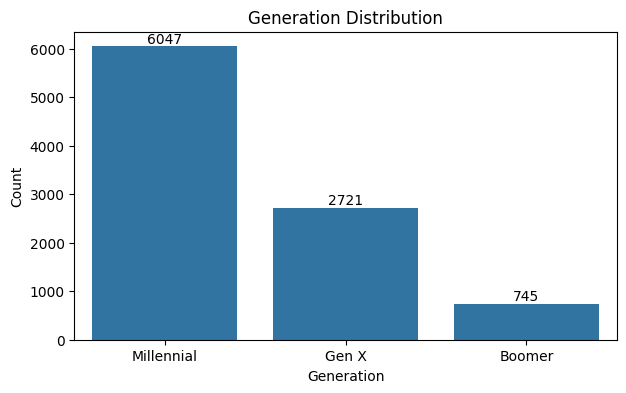

In [39]:
plt.figure(figsize=(7, 4))

ax = sns.countplot(
    data=df,
    x="generation",
    order=generation_labels
)

ax.bar_label(ax.containers[0])

plt.title("Generation Distribution")
plt.xlabel("Generation")
plt.ylabel("Count")
plt.show()

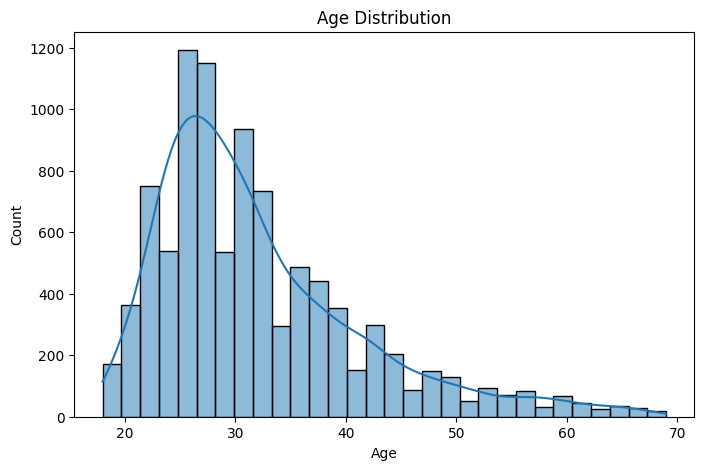

In [40]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

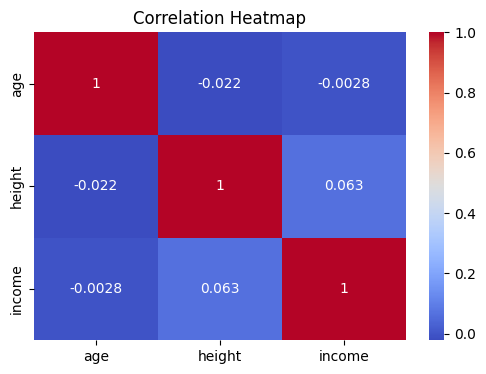

In [41]:
numeric_cols = ["age", "height", "income"]

plt.figure(figsize=(6, 4))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

## Feature Preprocessing

The same structured profile features are used for both tasks.

Missing numerical values are filled with the median. Missing categorical values are replaced with `"unknown"`. Categorical variables are then converted into dummy variables.

In [42]:
numeric_features = [
    "height",
    "income"
]

categorical_features = [
    "sex",
    "orientation",
    "body_type",
    "diet",
    "drinks",
    "drugs",
    "education",
    "job",
    "smokes",
    "status"
]

model_df = df[numeric_features + categorical_features].copy()

In [43]:
# Fill missing numerical values
for col in numeric_features:
    model_df[col] = model_df[col].fillna(model_df[col].median())

# Fill missing categorical values
for col in categorical_features:
    model_df[col] = model_df[col].fillna("unknown")

# Convert categorical variables to numerical dummy variables
x = pd.get_dummies(
    model_df,
    drop_first=True,
    dtype=int
)

X.shape

(9513, 104)

# Part 1 — Regression: Predicting Age

The first task predicts the user's **age** from the selected dating-profile features.

A small feed-forward neural network is used for the regression task.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

y_age = df["age"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y_age,
    test_size=0.20,
    random_state=42
)

scaler_reg = StandardScaler()

x_train_scaled = scaler_reg.fit_transform(x_train)
x_test_scaled = scaler_reg.transform(x_test)

## Regression Model

In [45]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)

reg_model = Sequential([
    Input(shape=(x_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1)
])

reg_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

reg_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 64)                  │           6,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

## Regression Training

In [46]:
early_stopping_reg = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_reg = reg_model.fit(
    x_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping_reg],
    verbose=1
)

Epoch 1/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 796.6497 - mae: 25.3354 - val_loss: 86.7011 - val_mae: 6.9009
Epoch 2/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 84.7506 - mae: 6.8098 - val_loss: 77.6021 - val_mae: 6.5743
Epoch 3/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 74.0959 - mae: 6.4417 - val_loss: 75.8653 - val_mae: 6.4917
Epoch 4/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 69.8894 - mae: 6.2793 - val_loss: 75.0575 - val_mae: 6.4358
Epoch 5/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 67.1612 - mae: 6.1612 - val_loss: 74.5989 - val_mae: 6.3994
Epoch 6/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 65.1530 - mae: 6.0635 - val_loss: 74.3555 - val_mae: 6.3739
Epoch 7/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 63.6270 - mae: 5.9825 - val_loss: 74.2081 - val_mae: 6.3515
Epoch 8/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 62.3839 - mae: 5.9137 - val_loss: 74.1544 - val_mae: 6.3378
Epoch 9/30
191/191 ━━━━━━━━━━━━━━━━━━━

## Regression Evaluation

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

age_predictions = reg_model.predict(
    x_test_scaled,
    verbose=0
).ravel()

mae = mean_absolute_error(y_test, age_predictions)
rmse = mean_squared_error(y_test, age_predictions) ** 0.5
r2 = r2_score(y_test, age_predictions)

print("Regression Results")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R² Score:", round(r2, 4))

Regression Results
MAE: 5.9479
RMSE: 7.9998
R² Score: 0.1926


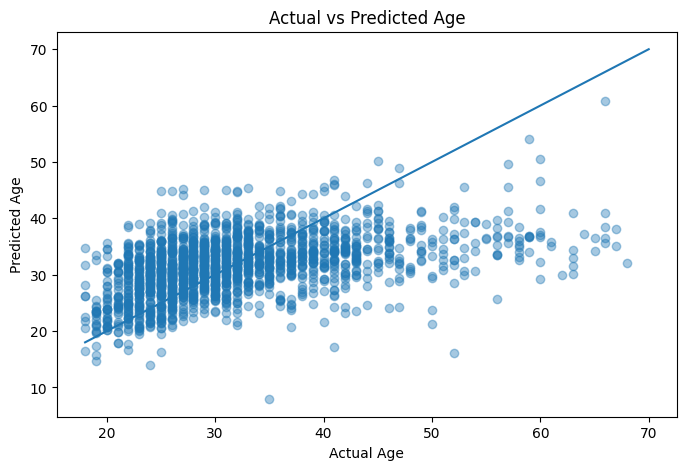

In [48]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    age_predictions,
    alpha=0.4
)

plt.plot(
    [18, 70],
    [18, 70]
)

plt.title("Actual vs Predicted Age")
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.show()

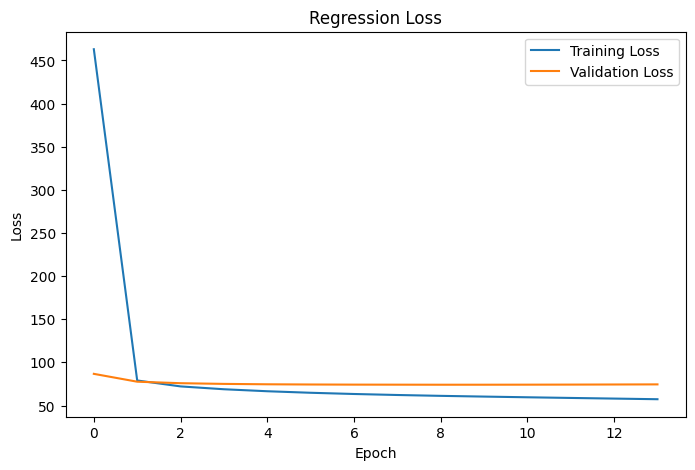

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(history_reg.history["loss"], label="Training Loss")
plt.plot(history_reg.history["val_loss"], label="Validation Loss")

plt.title("Regression Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Part 2 — Classification: Predicting Generation

The second task predicts whether a user belongs to the **Millennial**, **Gen X**, or **Boomer** generation.

A neural network with a softmax output layer is used for the classification task.

In [50]:
generation_map = {
    "Millennial": 0,
    "Gen X": 1,
    "Boomer": 2
}

y_generation = df["generation"].map(generation_map).astype(int)

x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(
    x,
    y_generation,
    test_size=0.20,
    random_state=42,
    stratify=y_generation
)

scaler_clf = StandardScaler()

x_train_c_scaled = scaler_clf.fit_transform(X_train_c)
x_test_c_scaled = scaler_clf.transform(X_test_c)

## Classification Model

In [51]:
tf.keras.utils.set_random_seed(42)

clf_model = Sequential([
    Input(shape=(X_train_c_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])

clf_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

clf_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 64)                  │           6,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,899 (34.76 KB)

 Trainable params: 8,899 (34.76 KB)

 Non-trainable params: 0 (0.00 B)

## Classification Training

In [52]:
early_stopping_clf = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_clf = clf_model.fit(
    x_train_c_scaled,
    y_train_c,
    validation_split=0.20,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping_clf],
    verbose=1
)

Epoch 1/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5593 - loss: 0.9473 - val_accuracy: 0.6413 - val_loss: 0.7956
Epoch 2/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6659 - loss: 0.7420 - val_accuracy: 0.6491 - val_loss: 0.7871
Epoch 3/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6716 - loss: 0.7128 - val_accuracy: 0.6537 - val_loss: 0.7895
Epoch 4/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6853 - loss: 0.6923 - val_accuracy: 0.6426 - val_loss: 0.7957
Epoch 5/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6910 - loss: 0.6744 - val_accuracy: 0.6459 - val_loss: 0.8029
Epoch 6/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7009 - loss: 0.6576 - val_accuracy: 0.6413 - val_loss: 0.8124
Epoch 7/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7074 - loss: 0.6420 - val_accuracy: 0.6353 - val_loss: 0.8246


## Classification Evaluation

In [53]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

generation_probabilities = clf_model.predict(
    x_test_c_scaled,
    verbose=0
)

generation_predictions = np.argmax(
    generation_probabilities,
    axis=1
)

accuracy = accuracy_score(
    y_test_c,
    generation_predictions
)

print("Classification Accuracy:", round(accuracy, 4))
print()

print(
    classification_report(
        y_test_c,
        generation_predictions,
        target_names=generation_labels
    )
)

Classification Accuracy: 0.6495

              precision    recall  f1-score   support

  Millennial       0.70      0.89      0.78      1210
       Gen X       0.46      0.27      0.34       544
      Boomer       0.31      0.07      0.11       149

    accuracy                           0.65      1903
   macro avg       0.49      0.41      0.41      1903
weighted avg       0.60      0.65      0.60      1903



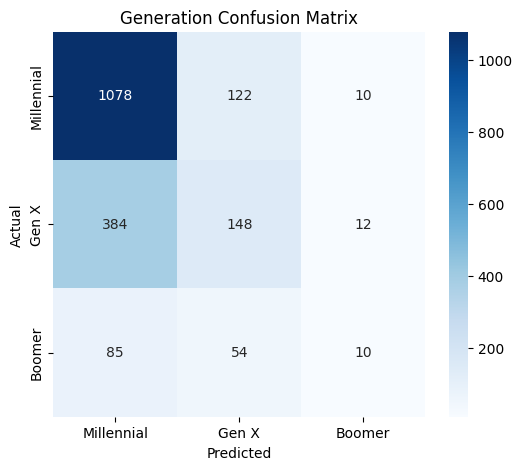

In [54]:
cm = confusion_matrix(
    y_test_c,
    generation_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=generation_labels,
    yticklabels=generation_labels
)

plt.title("Generation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

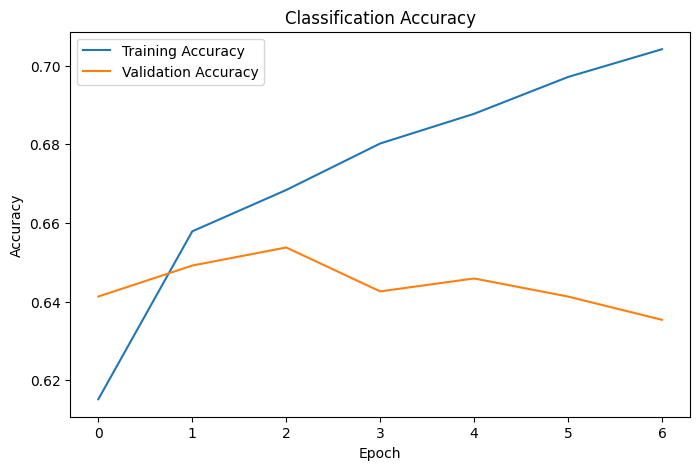

In [55]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_clf.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_clf.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Conclusion

This project applies supervised deep learning to two prediction tasks using structured OKCupid profile information.

For the **regression task**, the model predicts user age with:

- **MAE:** 5.9479
- **RMSE:** 7.9998
- **R² Score:** 0.1926

The regression results indicate that the selected structured profile features provide limited information for predicting a user's exact age.

For the **classification task**, the model achieved an overall accuracy of **64.95%** when predicting whether a user belongs to the Millennial, Gen X, or Boomer generation.

The model performs best for the Millennial group, while performance is lower for Gen X and especially Boomers. This is influenced by the unequal distribution of the three generation groups in the dataset.

Overall, the project presents a complete workflow for data preparation, feature engineering, deep learning regression, multi-class classification, evaluation, and visualization.